# Healthcare Claims EDA
## Week 2 — Exploratory Data Analysis
This notebook explores the CMS Medicare Physician & Other Practitioners 
by Provider and Service dataset (2024) to identify patterns relevant 
to claim denial prediction, anomaly detection, and ICD code classification.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load a sample of 500,000 rows — full file is 3.25GB
df = pd.read_csv('../data/raw/PHY_R26_P05_V10_D24_Prov_Svc.csv', nrows=500000, low_memory=False)
print(df.shape)
df.head()

(500000, 28)


,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_St2,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,...,HCPCS_Desc,HCPCS_Drug_Ind,Place_Of_Srvc,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
0,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Initial hospital care with straightforward or ...,N,F,36,36.0,36,284.378889,79.063889,60.828889,62.376389
1,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Initial hospital care with straightforward or ...,N,F,150,150.0,150,352.176333,126.340800,95.675600,96.007133
2,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Initial hospital care with moderate level of m...,N,F,63,63.0,63,783.997302,170.360000,134.300476,131.999365
3,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Subsequent hospital care with straightforward ...,N,F,11,16.0,16,122.125000,47.832500,33.350625,33.706250
4,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Subsequent hospital care with moderate levelof...,N,F,37,70.0,70,583.606857,81.428571,62.728714,58.486857


## Non-Essential Features
The following columns contain missing values but are not required for analysis:

| Column | Description | Reason Excluded |
|--------|-------------|-----------------|
| `Rndrng_Prvdr_First_Name` | Provider first name | Name details not needed for modeling |
| `Rndrng_Prvdr_MI` | Provider middle initial | Name details not needed for modeling |
| `Rndrng_Prvdr_Crdntls` | Provider credentials | Not a predictive feature |
| `Rndrng_Prvdr_St2` | Street address line 2 | Address details irrelevant to analysis |
| `Rndrng_Prvdr_RUCA` | Rural/urban classification | Not a core feature for denial prediction |

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Rndrng_NPI                     500000 non-null  int64  
 1   Rndrng_Prvdr_Last_Org_Name     500000 non-null  object 
 2   Rndrng_Prvdr_First_Name        476329 non-null  object 
 3   Rndrng_Prvdr_MI                323435 non-null  object 
 4   Rndrng_Prvdr_Crdntls           443825 non-null  object 
 5   Rndrng_Prvdr_Ent_Cd            500000 non-null  object 
 6   Rndrng_Prvdr_St1               500000 non-null  object 
 7   Rndrng_Prvdr_St2               111382 non-null  object 
 8   Rndrng_Prvdr_City              500000 non-null  object 
 9   Rndrng_Prvdr_State_Abrvtn      500000 non-null  object 
 10  Rndrng_Prvdr_State_FIPS        500000 non-null  object 
 11  Rndrng_Prvdr_Zip5              500000 non-null  int64  
 12  Rndrng_Prvdr_RUCA             

In [7]:
df.describe()

,Rndrng_NPI,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_RUCA,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
count,5.000000e+05,500000.000000,499671.000000,500000.000000,5.000000e+05,500000.00000,500000.000000,500000.000000,500000.000000,500000.000000
mean,1.024155e+09,47859.972556,1.559688,76.969232,2.967334e+02,126.49672,430.031543,107.141456,83.606181,83.246602
std,1.476677e+07,28865.483166,3.552741,345.058621,9.905060e+03,646.36362,1562.243986,336.662436,268.560425,274.559494
min,1.003000e+09,602.000000,1.000000,11.000000,1.100000e+01,11.00000,0.000148,0.000000,0.000000,0.000000
25%,1.013201e+09,23507.000000,1.000000,17.000000,2.100000e+01,20.00000,72.941620,25.423473,19.584207,19.387509
50%,1.023285e+09,44116.500000,1.000000,32.000000,4.400000e+01,41.00000,178.808977,71.492902,52.455000,52.643904
75%,1.033645e+09,75115.000000,1.000000,72.000000,1.200000e+02,107.00000,366.000000,121.086331,90.890264,90.787273
max,1.053324e+09,99925.000000,99.000000,67989.000000,4.265051e+06,165514.00000,99999.990000,28706.684615,22871.990000,20280.797925


## Data Quality Check — Findings

- **No duplicate rows** — dataset is clean on this front
- **No missing values** in any column essential to analysis
- **Missing values only in non-essential columns** — provider name 
  details, address line 2, and RUCA codes — all previously identified 
  as excluded from modeling
- **RUCA missing 329 rows** — consistent with the 499,671 non-null 
  count seen in df.info(); CMS codes unknown rural/urban classification 
  as NaN rather than 99 in some cases

Overall the dataset is in good shape and requires no cleaning 
for the columns relevant to this project.

In [8]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Rndrng_NPI                            0
Rndrng_Prvdr_Last_Org_Name            0
Rndrng_Prvdr_First_Name           23671
Rndrng_Prvdr_MI                  176565
Rndrng_Prvdr_Crdntls              56175
Rndrng_Prvdr_Ent_Cd                   0
Rndrng_Prvdr_St1                      0
Rndrng_Prvdr_St2                 388618
Rndrng_Prvdr_City                     0
Rndrng_Prvdr_State_Abrvtn             0
Rndrng_Prvdr_State_FIPS               0
Rndrng_Prvdr_Zip5                     0
Rndrng_Prvdr_RUCA                   329
Rndrng_Prvdr_RUCA_Desc              329
Rndrng_Prvdr_Cntry                    0
Rndrng_Prvdr_Type                     0
Rndrng_Prvdr_Mdcr_Prtcptg_Ind         0
HCPCS_Cd                              0
HCPCS_Desc                            0
HCPCS_Drug_Ind                        0
Place_Of_Srvc                         0
Tot_Benes                             0
Tot_Srvcs                             0
Tot_Bene_Day_Srvcs                    0
Avg_Sbmtd_Chr

## Chart 3 Insight — Top 20 HCPCS Codes by Total Services

The top code by volume is Factor VIII (antihemophilic factor), a hemophilia 
medication billed per international unit rather than per patient encounter. 
This inflates Tot_Srvcs significantly and illustrates that raw service counts 
can be misleading across different procedure types — one patient infusion can 
generate thousands of billed service units. Volume metrics should therefore 
be interpreted within procedure category context rather than as a direct 
proxy for patient encounter frequency.

Below Factor VIII, office visit and evaluation & management (E&M) codes 
dominate Medicare billing volume, consistent with expectations. "Established 
patient office visit" codes appear multiple times across different complexity 
levels, confirming that E&M codes make up the bulk of Medicare claims. This 
has two implications for synthetic data generation: E&M codes should be 
heavily weighted to reflect real-world distribution, and they represent the 
highest upcoding risk due to their frequency and multiple complexity tiers 
(billing 99214 when 99213 was appropriate is one of the most common fraud 
patterns in Medicare).

The remaining top codes include injections, therapy procedures, and contrast 
materials — reflecting Medicare's predominantly aging patient population with 
chronic conditions requiring ongoing treatment.

/var/folders/h9/49xfg8x17wl2czyg0zl1_8_m0000gn/T/ipykernel_29406/172615362.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


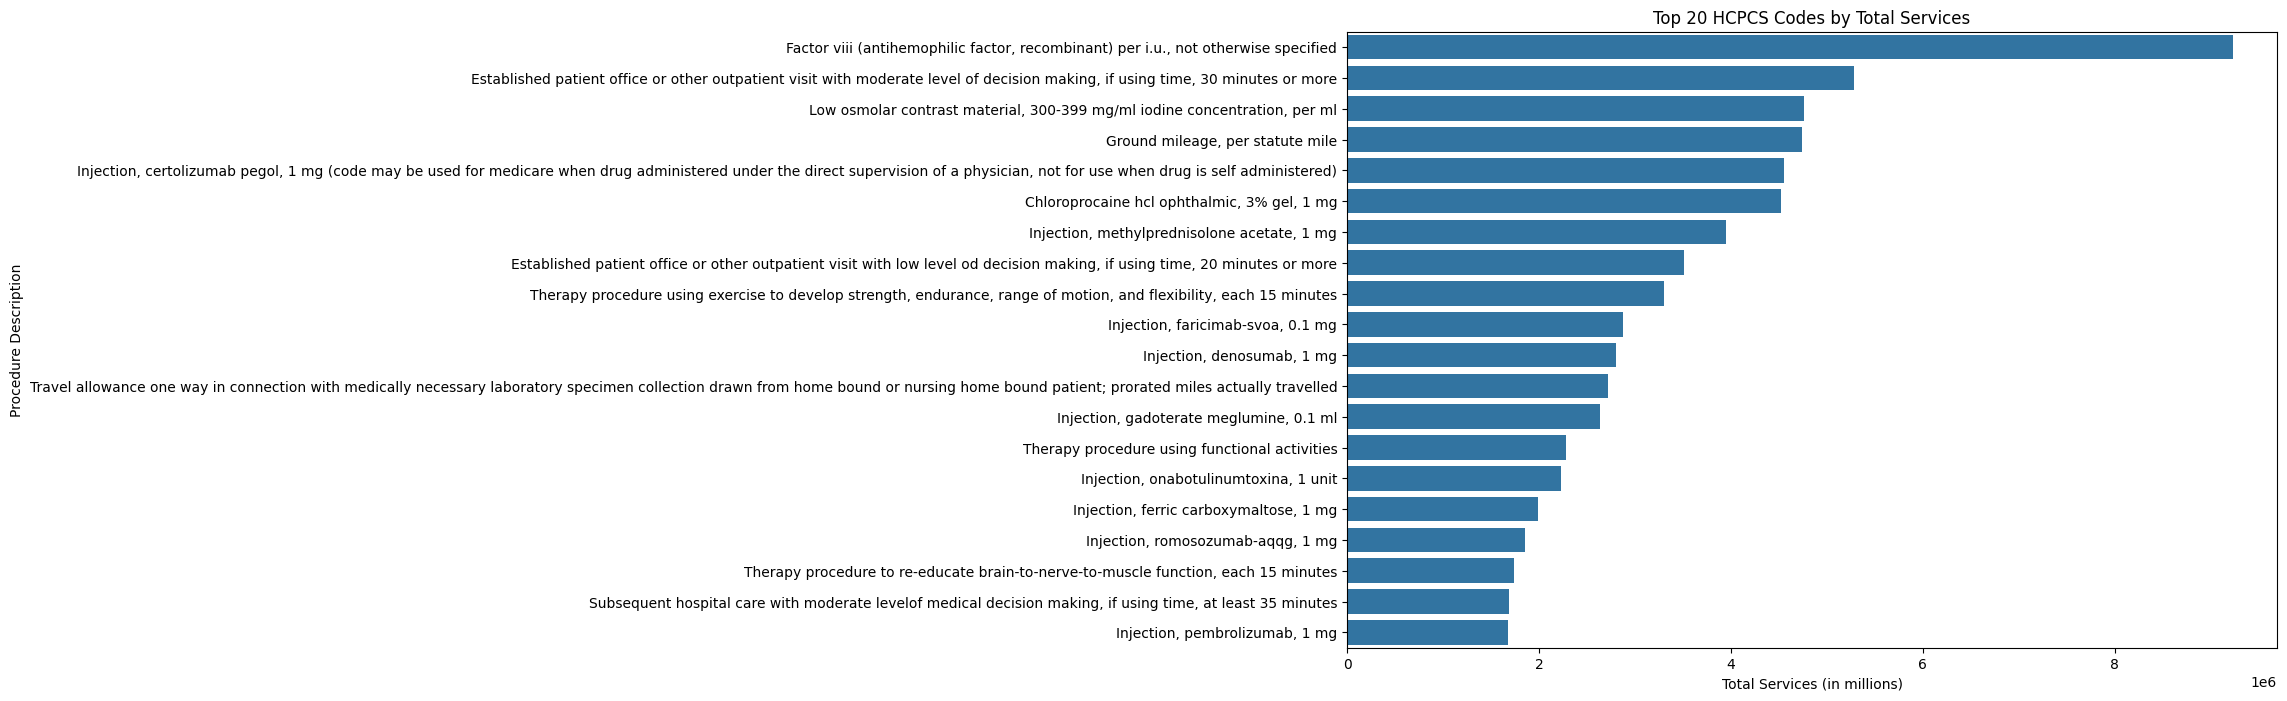

In [15]:
top20_cpt = (df.groupby(['HCPCS_Cd', 'HCPCS_Desc'])['Tot_Srvcs']
               .sum()
               .sort_values(ascending=False)
               .head(20)
               .reset_index())

plt.figure(figsize=(12, 8))
sns.barplot(data=top20_cpt, x='Tot_Srvcs', y='HCPCS_Desc')
plt.title('Top 20 HCPCS Codes by Total Services')
plt.xlabel('Total Services (in millions)')
plt.ylabel('Procedure Description')
plt.tight_layout()
plt.show()